In [ ]:
import numpy as np


def gcn_layer(A, X, W):
    N = A.shape[0]
    A_tilde = A + np.eye(N)
    d = A_tilde.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt
    return np.maximum(0, A_hat @ (X @ W))
# Do Â(XW) first. Either order has one big N x N multiply, but doing X times W
# first makes that matrix narrower beforehand, so the heavy step has less to
# compute. This holds as long as the output width is not larger than the input.

A = np.array([[0, 1, 0],
              [1, 0, 1],
              [0, 1, 0]], dtype=float)

np.random.seed(0)
X = np.random.randn(3, 4)
W = np.random.randn(4, 2)

H = gcn_layer(A, X, W)
print(H)

[[2.80530784 0.        ]
 [2.60658792 0.        ]
 [1.35041084 0.        ]]


In [4]:
import numpy as np
import networkx as nx

G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
N = A.shape[0]


d = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
additive = np.eye(N) + D_inv_sqrt @ A @ D_inv_sqrt

A_tilde = A + np.eye(N)
d_tilde = A_tilde.sum(axis=1)
D_tilde_inv_sqrt = np.diag(1.0 / np.sqrt(d_tilde))
renorm = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt

e1 = np.linalg.eigvalsh(additive)
e2 = np.linalg.eigvalsh(renorm)

print("I + D^-1/2 A D^-1/2  ->  min %.4f   max %.4f" % (e1.min(), e1.max()))
print("renormalized A_hat   ->  min %.4f   max %.4f" % (e2.min(), e2.max()))

I + D^-1/2 A D^-1/2  ->  min 0.3078   max 2.0000
renormalized A_hat   ->  min -0.5819   max 1.0000


Processing...
Done!


K =  2  ->  test accuracy 0.8150
K =  4  ->  test accuracy 0.7730
K =  8  ->  test accuracy 0.6770
K = 16  ->  test accuracy 0.3940


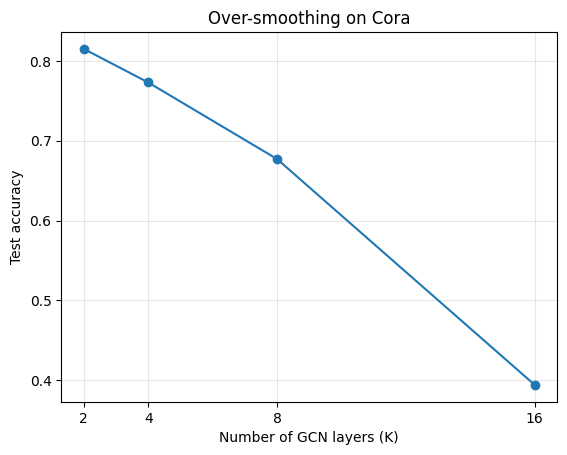

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

torch.manual_seed(0)
dataset = Planetoid(root="data/Cora", name="Cora")
data = dataset[0]


class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim, K):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden))   #
        for _ in range(K - 2):
            self.convs.append(GCNConv(hidden, hidden))  
        self.convs.append(GCNConv(hidden, out_dim))  

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = F.relu(conv(x, edge_index))
        return self.convs[-1](x, edge_index)          


def train_eval(K, epochs=200):
    model = GCN(dataset.num_features, 16, dataset.num_classes, K)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        F.cross_entropy(out[data.train_mask], data.y[data.train_mask]).backward()
        opt.step()
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    return int(correct) / int(data.test_mask.sum())


Ks = [2, 4, 8, 16]
accs = []
for K in Ks:
    acc = train_eval(K)
    accs.append(acc)
    print(f"K = {K:2d}  ->  test accuracy {acc:.4f}")

plt.plot(Ks, accs, marker="o")
plt.xlabel("Number of GCN layers (K)")
plt.ylabel("Test accuracy")
plt.title("Over-smoothing on Cora")
plt.xticks(Ks)
plt.grid(True, alpha=0.3)
plt.show()

